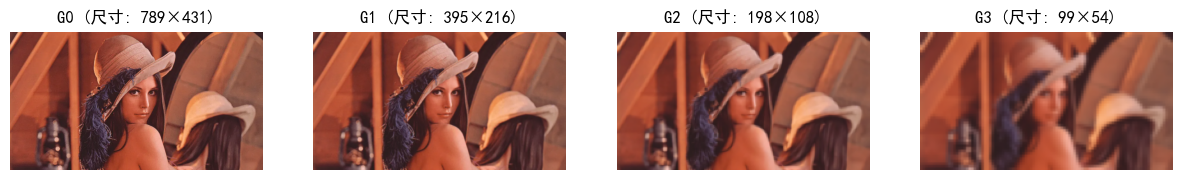

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["SimHei"]  # 指定支持中文的黑体字体
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示为方块的问题

# 1. 读取原始图像（G0层，底层高斯图像）
img = cv2.imread("lena.jpeg")  # 替换成你的图像路径
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # 转换颜色空间（OpenCV默认BGR，Matplotlib默认RGB）
G0 = img.copy()
gaussian_pyramid = [G0]  # 存储高斯金字塔的所有层级

# 2. 构建高斯金字塔（生成G1、G2、G3层，可按需调整层数）
layers = 3  # 金字塔层数（不含原始层G0）
for i in range(layers):
    # 先高斯模糊，再下采样（OpenCV的pyrDown函数直接实现“先模糊后缩小”，对应我们的公式）
    Gi = cv2.pyrDown(gaussian_pyramid[-1])
    gaussian_pyramid.append(Gi)

# 3. 展示高斯金字塔各层效果
plt.figure(figsize=(15, 10))
for i, Gi in enumerate(gaussian_pyramid):
    plt.subplot(1, len(gaussian_pyramid), i+1)
    plt.title(f"G{i} (尺寸: {Gi.shape[1]}×{Gi.shape[0]})")
    plt.imshow(Gi)
    plt.axis("off")
plt.show()



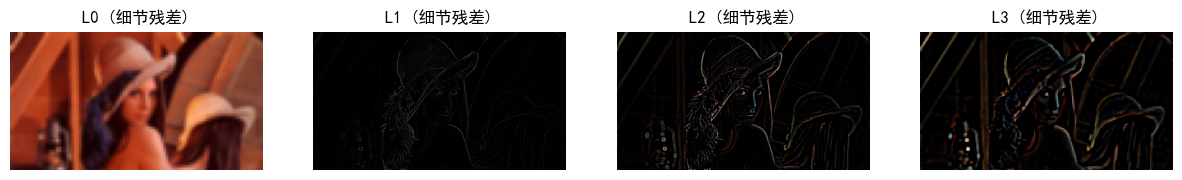

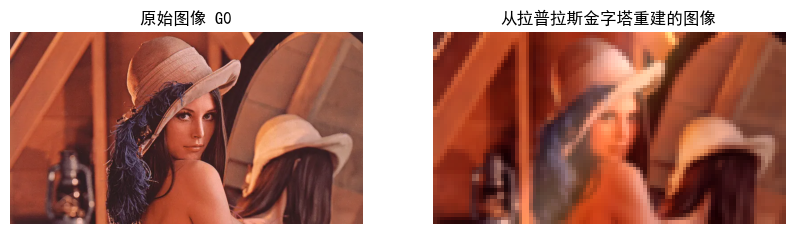

In [16]:
# 注意：该代码需要基于上面的高斯金字塔结果运行（先构建高斯金字塔，再构建拉普拉斯金字塔）
laplacian_pyramid = []

# 1. 构建拉普拉斯金字塔（从高斯金字塔的最上层往底层构建）
for i in range(len(gaussian_pyramid)-1, 0, -1):
    # 步骤1：将当前层高斯图像上采样（放大2倍），得到和上一层（G[i-1]）尺寸相同的图像
    Gi_upsample = cv2.pyrUp(gaussian_pyramid[i])

    # 步骤2：裁剪尺寸（避免上采样后尺寸略有偏差，保证和G[i-1]完全一致）
    Gi_upsample = Gi_upsample[:gaussian_pyramid[i-1].shape[0], :gaussian_pyramid[i-1].shape[1]]

    # 步骤3：计算拉普拉斯图像（G[i-1] - 上采样后的G[i]），即细节残差
    Li_1 = cv2.subtract(gaussian_pyramid[i-1], Gi_upsample)
    laplacian_pyramid.append(Li_1)

# 2. 补充最上层拉普拉斯图像（高斯金字塔最上层无更高层，直接用自身作为残差）
laplacian_pyramid.append(gaussian_pyramid[-1])
# 反转列表，让拉普拉斯金字塔层级和高斯金字塔对应（L0→L3）
laplacian_pyramid.reverse()

# 3. 展示拉普拉斯金字塔各层效果
plt.figure(figsize=(15, 10))
for i, Li in enumerate(laplacian_pyramid):
    # 拉普拉斯图像是残差，数值范围可能超出0-255，先归一化方便展示
    Li_normalized = cv2.normalize(Li, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    plt.subplot(1, len(laplacian_pyramid), i+1)
    plt.title(f"L{i} (细节残差)")
    plt.imshow(Li_normalized, cmap="gray")  # 用灰度图展示细节更清晰
    plt.axis("off")
plt.show()

# 4. 额外补充：从拉普拉斯金字塔重建原始图像（验证残差的作用）
reconstructed_img = laplacian_pyramid[-1]
for i in range(len(laplacian_pyramid)-2, -1, -1):
    reconstructed_img = cv2.pyrUp(reconstructed_img)
    reconstructed_img = reconstructed_img[:laplacian_pyramid[i].shape[0], :laplacian_pyramid[i].shape[1]]
    reconstructed_img = cv2.add(reconstructed_img, laplacian_pyramid[i])

# 展示重建结果
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("原始图像 G0")
plt.imshow(G0)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("从拉普拉斯金字塔重建的图像")
plt.imshow(cv2.normalize(reconstructed_img, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U))
plt.axis("off")
plt.show()



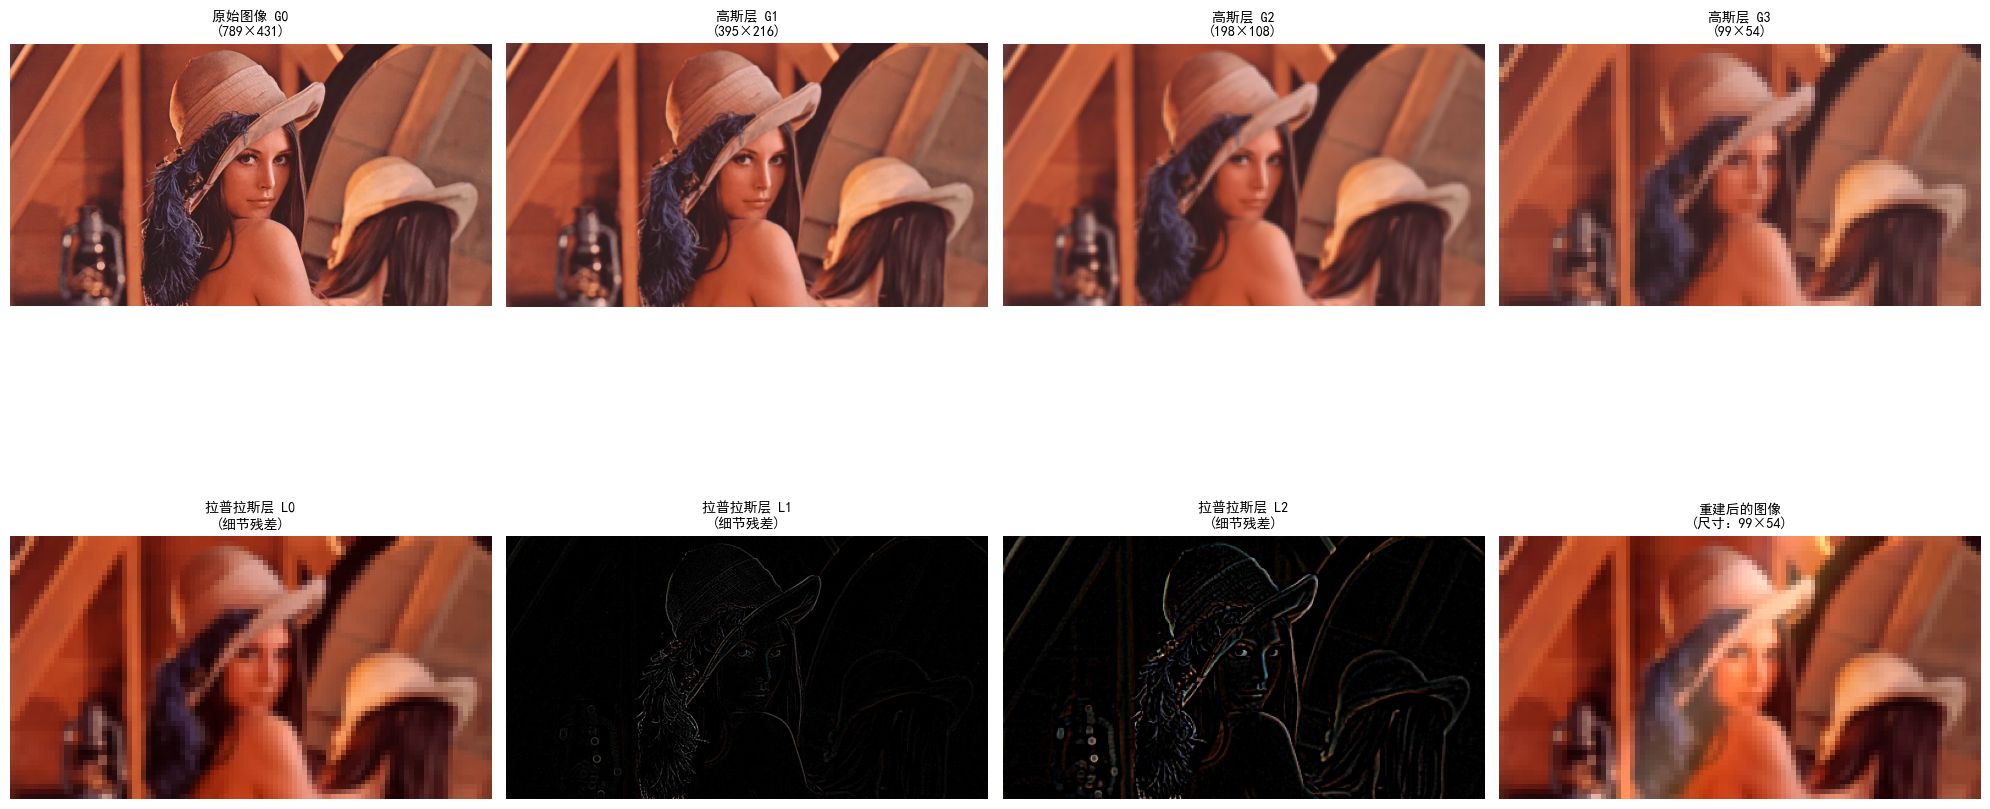

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------- 1. 读取并预处理图像 --------------------------
# 读取 lena.jpeg（确保图像路径正确，若在同级目录直接用文件名）
img = cv2.imread("lena.jpeg")
if img is None:
    raise FileNotFoundError("请检查 lena.jpeg 的路径是否正确！")

# 转换颜色空间（OpenCV默认BGR，Matplotlib默认RGB，保证显示正常）
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
G0 = img_rgb.copy()  # G0：原始图像（高斯金字塔底层）

# -------------------------- 2. 构建高斯金字塔 --------------------------
gaussian_pyramid = [G0]  # 存储高斯金字塔所有层级
layers = 3  # 生成3层（G1、G2、G3），可调整层数

for i in range(layers):
    # pyrDown：自动完成“高斯模糊→下采样”，尺寸减半
    Gi = cv2.pyrDown(gaussian_pyramid[-1])
    gaussian_pyramid.append(Gi)

# -------------------------- 3. 构建拉普拉斯金字塔 --------------------------
laplacian_pyramid = []

# 从高斯金字塔最上层往底层构建（记录每层丢失的细节）
for i in range(len(gaussian_pyramid)-1, 0, -1):
    # 上采样：将当前层放大2倍
    Gi_upsample = cv2.pyrUp(gaussian_pyramid[i])
    # 裁剪尺寸：确保与上一层高斯图像完全匹配
    Gi_upsample = Gi_upsample[:gaussian_pyramid[i-1].shape[0], :gaussian_pyramid[i-1].shape[1]]
    # 计算残差（拉普拉斯图像）：G[i-1] - 放大后的G[i]
    Li = cv2.subtract(gaussian_pyramid[i-1], Gi_upsample)
    laplacian_pyramid.append(Li)

# 补充最上层拉普拉斯图像（无更高层，直接用高斯最上层）
laplacian_pyramid.append(gaussian_pyramid[-1])
laplacian_pyramid.reverse()  # 反转后与高斯金字塔层级对应（L0→L3）

# -------------------------- 4. 从拉普拉斯金字塔重建原图 --------------------------
reconstructed_img = laplacian_pyramid[-1]  # 从最上层开始
for i in range(len(laplacian_pyramid)-2, -1, -1):
    reconstructed_img = cv2.pyrUp(reconstructed_img)
    # 裁剪尺寸匹配
    reconstructed_img = reconstructed_img[:laplacian_pyramid[i].shape[0], :laplacian_pyramid[i].shape[1]]
    # 叠加当前层残差
    reconstructed_img = cv2.add(reconstructed_img, laplacian_pyramid[i])

# 归一化重建结果（确保像素值在0-255，避免显示异常）
reconstructed_img = cv2.normalize(reconstructed_img, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

# # 关键：转换颜色空间（Matplotlib中是RGB，OpenCV保存需要BGR）
# reconstructed_img_bgr = cv2.cvtColor(reconstructed_img, cv2.COLOR_RGB2BGR)
#
# # 保存图像到本地（同级目录下，文件名可自定义）
# cv2.imwrite("lena_reconstructed.jpeg", reconstructed_img_bgr)
# print("重建后的图像已保存为：lena_reconstructed.jpeg")

# -------------------------- 5. 可视化所有结果 --------------------------
plt.figure(figsize=(20, 12))

# 5.1 显示高斯金字塔
plt.subplot(2, 4, 1)
plt.title("原始图像 G0\n({}×{})".format(G0.shape[1], G0.shape[0]), fontsize=10)
plt.imshow(G0)
plt.axis("off")

for i in range(1, len(gaussian_pyramid)):
    plt.subplot(2, 4, i+1)
    plt.title(f"高斯层 G{i}\n({gaussian_pyramid[i].shape[1]}×{gaussian_pyramid[i].shape[0]})", fontsize=10)
    plt.imshow(gaussian_pyramid[i])
    plt.axis("off")

# 5.2 显示拉普拉斯金字塔（灰度图更清晰展示细节）
for i in range(len(laplacian_pyramid)):
    # 归一化残差图像，方便显示
    Li_norm = cv2.normalize(laplacian_pyramid[i], None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    plt.subplot(2, 4, len(gaussian_pyramid)+i+1)
    plt.title(f"拉普拉斯层 L{i}\n(细节残差)", fontsize=10)
    plt.imshow(Li_norm, cmap="gray")
    plt.axis("off")

# 5.3 显示重建结果对比
plt.subplot(2, 4, 8)
plt.title("重建后的图像\n(尺寸：{}×{})".format(reconstructed_img.shape[1], reconstructed_img.shape[0]), fontsize=10)
plt.imshow(reconstructed_img)
plt.axis("off")

plt.tight_layout()
plt.show()

✅ 重建图像已成功保存至：lena_reconstructed_final.jpeg
✅ 保存图像尺寸：99×54


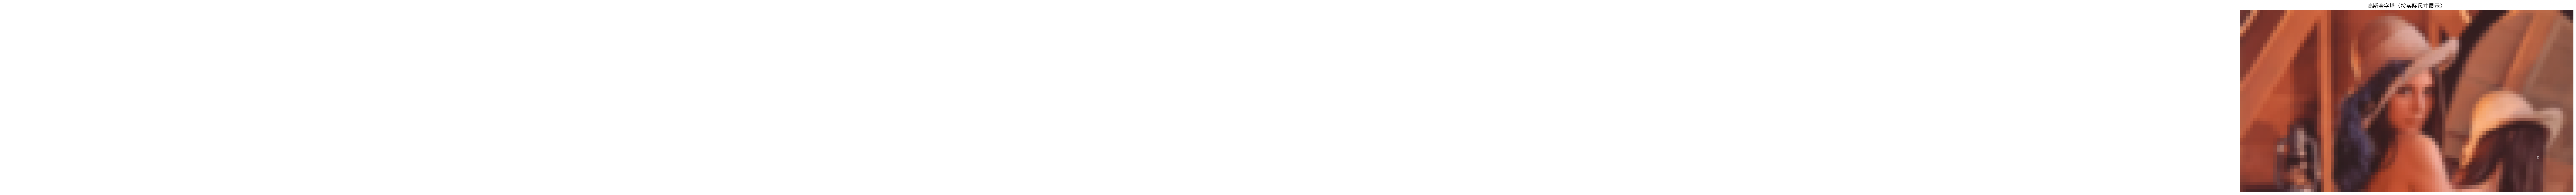

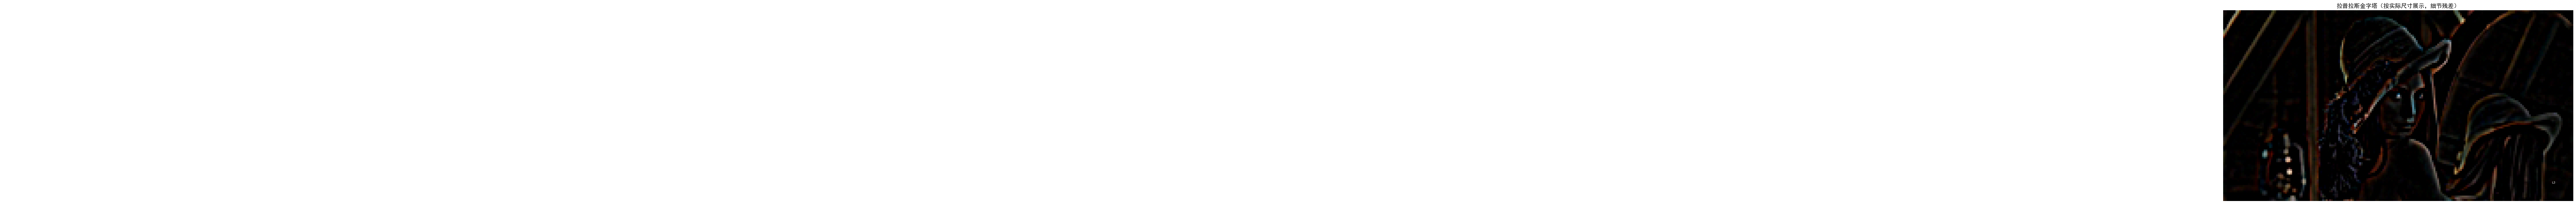

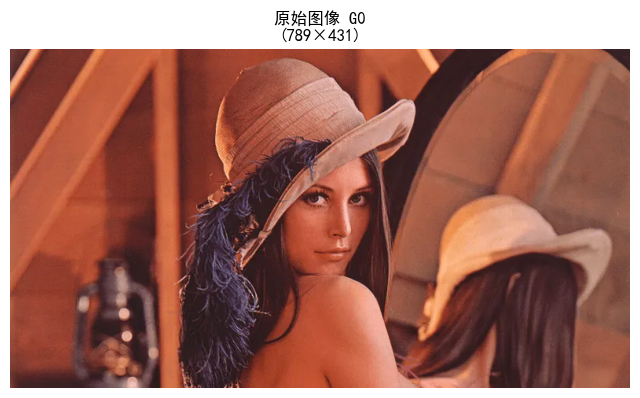

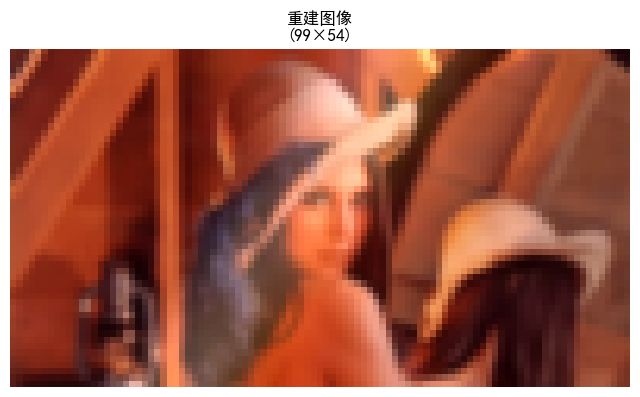

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------- 1. 读取并预处理图像 --------------------------
# 读取 lena.jpeg（确保图像路径正确，若在同级目录直接用文件名）
img = cv2.imread("lena.jpeg")
if img is None:
    raise FileNotFoundError("请检查 lena.jpeg 的路径是否正确！")

# 转换颜色空间（OpenCV默认BGR，Matplotlib默认RGB，保证显示正常）
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
G0 = img_rgb.copy()  # G0：原始图像（高斯金字塔底层）

# -------------------------- 2. 构建高斯金字塔 --------------------------
gaussian_pyramid = [G0]  # 存储高斯金字塔所有层级
layers = 3  # 生成3层（G1、G2、G3），可调整层数

for i in range(layers):
    # pyrDown：自动完成“高斯模糊→下采样”，尺寸减半
    Gi = cv2.pyrDown(gaussian_pyramid[-1])
    gaussian_pyramid.append(Gi)

# -------------------------- 3. 构建拉普拉斯金字塔 --------------------------
laplacian_pyramid = []

# 从高斯金字塔最上层往底层构建（记录每层丢失的细节）
for i in range(len(gaussian_pyramid)-1, 0, -1):
    # 上采样：将当前层放大2倍
    Gi_upsample = cv2.pyrUp(gaussian_pyramid[i])
    # 裁剪尺寸：确保与上一层高斯图像完全匹配
    Gi_upsample = Gi_upsample[:gaussian_pyramid[i-1].shape[0], :gaussian_pyramid[i-1].shape[1]]
    # 计算残差（拉普拉斯图像）：G[i-1] - 放大后的G[i]
    Li = cv2.subtract(gaussian_pyramid[i-1], Gi_upsample)
    laplacian_pyramid.append(Li)

# 补充最上层拉普拉斯图像（无更高层，直接用高斯最上层）
laplacian_pyramid.append(gaussian_pyramid[-1])
laplacian_pyramid.reverse()  # 反转后与高斯金字塔层级对应（L0→L3）

# -------------------------- 4. 从拉普拉斯金字塔重建原图 --------------------------
reconstructed_img = laplacian_pyramid[-1]  # 从最上层开始
for i in range(len(laplacian_pyramid)-2, -1, -1):
    reconstructed_img = cv2.pyrUp(reconstructed_img)
    # 裁剪尺寸匹配
    reconstructed_img = reconstructed_img[:laplacian_pyramid[i].shape[0], :laplacian_pyramid[i].shape[1]]
    # 叠加当前层残差
    reconstructed_img = cv2.add(reconstructed_img, laplacian_pyramid[i])

# 归一化重建结果（确保像素值在0-255，避免显示异常）
reconstructed_img = cv2.normalize(reconstructed_img, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

# -------------------------- 新增：保存重建后的图像 --------------------------
# 关键：转换颜色空间（Matplotlib中使用RGB格式，OpenCV保存需要BGR格式，否则颜色颠倒）
reconstructed_img_bgr = cv2.cvtColor(reconstructed_img, cv2.COLOR_RGB2BGR)

# 保存图像到本地（同级目录下，文件名可自定义，支持jpeg、png等格式）
save_path = "lena_reconstructed_final.jpeg"  # 自定义保存文件名和格式
cv2.imwrite(save_path, reconstructed_img_bgr)

# 打印保存成功提示，方便确认
print(f"✅ 重建图像已成功保存至：{save_path}")
print(f"✅ 保存图像尺寸：{reconstructed_img.shape[1]}×{reconstructed_img.shape[0]}")

# -------------------------- 5. 可视化所有结果（按实际尺寸展示，原始/重建分开独立画布） --------------------------
# 5.1 可视化高斯金字塔（按实际尺寸堆叠，呈现金字塔形态）
plt.figure(figsize=(15, 10))
plt.title("高斯金字塔（按实际尺寸展示）", fontsize=14)

# 初始偏移量（x从0开始，y从0开始）
x_offset = 0
y_offset = 0

for i, Gi in enumerate(gaussian_pyramid):
    # 绘制当前层高斯图像
    plt.imshow(Gi, extent=[x_offset, x_offset+Gi.shape[1], y_offset, y_offset+Gi.shape[0]])

    # 添加文字标注（在图像右上角）
    plt.text(x_offset+Gi.shape[1]-10, y_offset+10, f"G{i}", color="white", fontsize=8, ha="right")

    # 更新偏移量（下一张图放在当前图的右侧，y轴对齐顶部）
    x_offset += Gi.shape[1] + 20  # +20是留间距，避免图像重叠

# 关闭坐标轴，只显示图像
plt.axis("off")

# 5.2 可视化拉普拉斯金字塔（按实际尺寸展示，灰度图）
plt.figure(figsize=(15, 10))
plt.title("拉普拉斯金字塔（按实际尺寸展示，细节残差）", fontsize=14)

x_offset = 0
y_offset = 0

for i, Li in enumerate(laplacian_pyramid):
    # 归一化残差图像，方便显示
    Li_norm = cv2.normalize(Li, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

    # 绘制当前层拉普拉斯图像（灰度图）
    plt.imshow(Li_norm, cmap="gray", extent=[x_offset, x_offset+Li_norm.shape[1], y_offset, y_offset+Li_norm.shape[0]])

    # 添加文字标注
    plt.text(x_offset+Li_norm.shape[1]-10, y_offset+10, f"L{i}", color="white", fontsize=8, ha="right")

    # 更新偏移量
    x_offset += Li_norm.shape[1] + 20

plt.axis("off")

# 5.3 可视化原始图像（独立画布，正常比例）
plt.figure(figsize=(8, 6))  # 画布大小可根据图像调整
plt.title(f"原始图像 G0\n({G0.shape[1]}×{G0.shape[0]})", fontsize=12)
plt.imshow(G0)
plt.axis("off")  # 关闭坐标轴，只显示图像本身
plt.show()

# 5.4 可视化重建图像（独立画布，正常比例，与原始图像分开）
plt.figure(figsize=(8, 6))  # 画布大小可根据图像调整
plt.title(f"重建图像\n({reconstructed_img.shape[1]}×{reconstructed_img.shape[0]})", fontsize=12)
plt.imshow(reconstructed_img)
plt.axis("off")  # 关闭坐标轴，只显示图像本身
plt.show()

✅ 高斯金字塔构建完成，共 4 层（G0~G3）
✅ 拉普拉斯金字塔构建完成，共 4 层（L0~L3）
✅ 图像重建完成，重建流程共 4 步（L3→G2→G1→G0）


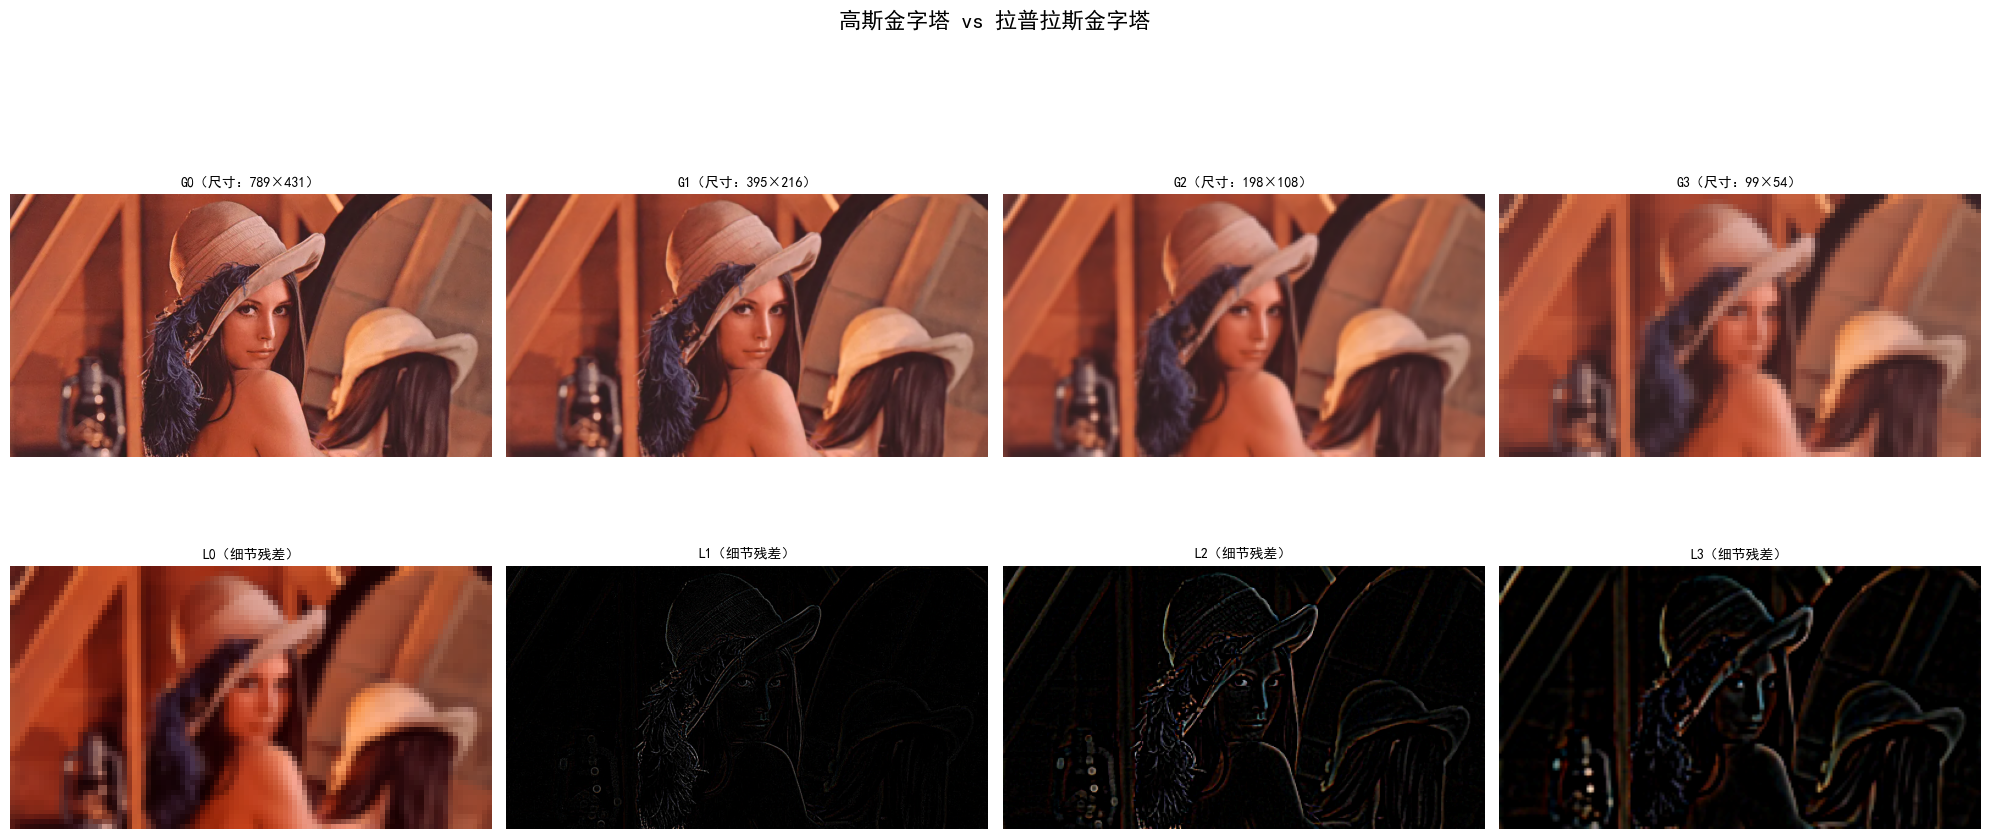

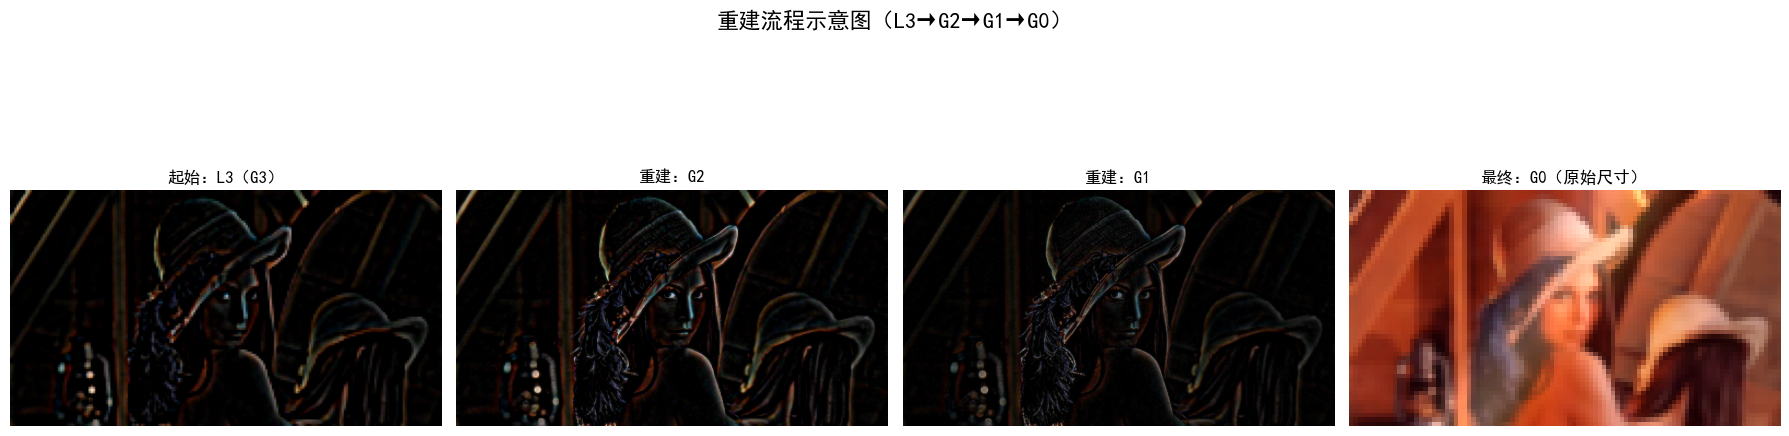

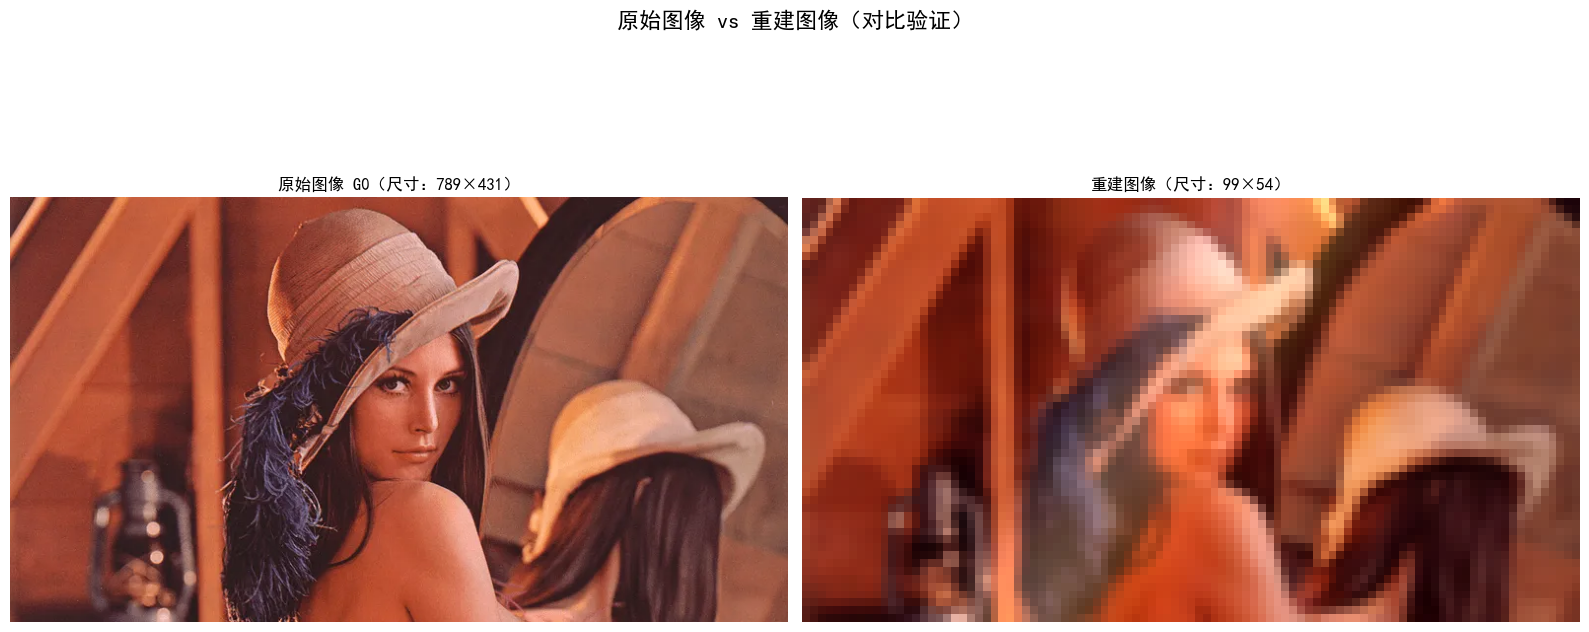

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------- 前置配置：支持中文显示 + 优化图表样式 --------------------------
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 指定黑体，支持中文标题/标注
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示为方块的问题

# -------------------------- 1. 读取并预处理图像 --------------------------
# 读取 lena.jpeg（确保图像路径正确，若在同级目录直接用文件名）
img = cv2.imread("lena.jpeg")
if img is None:
    raise FileNotFoundError("请检查 lena.jpeg 的路径是否正确！")

# 转换颜色空间（OpenCV默认BGR，Matplotlib默认RGB，保证显示正常无颜色偏差）
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
G0 = img_rgb.copy()  # G0：原始图像（高斯金字塔底层，尺寸最大）

# -------------------------- 2. 构建高斯金字塔（G0→G1→G2→G3） --------------------------
gaussian_pyramid = [G0]  # 存储高斯金字塔所有层级
layers = 3  # 生成3层（G1、G2、G3），最终金字塔共4层（G0~G3）

for i in range(layers):
    # pyrDown：自动完成“高斯模糊→下采样”，尺寸减半（宽/高各除以2）
    Gi = cv2.pyrDown(gaussian_pyramid[-1])
    gaussian_pyramid.append(Gi)

print(f"✅ 高斯金字塔构建完成，共 {len(gaussian_pyramid)} 层（G0~G{layers}）")

# -------------------------- 3. 构建拉普拉斯金字塔（L0→L1→L2→L3，细节残差） --------------------------
laplacian_pyramid = []

# 从高斯金字塔最上层（G3）往底层（G0）构建，记录每层丢失的细节残差
for i in range(len(gaussian_pyramid)-1, 0, -1):
    # 步骤1：将当前层高斯图像上采样（放大2倍），尝试还原上一层尺寸
    Gi_upsample = cv2.pyrUp(gaussian_pyramid[i])
    # 步骤2：裁剪尺寸（避免上采样后尺寸略有偏差，保证与G[i-1]完全一致）
    Gi_upsample = Gi_upsample[:gaussian_pyramid[i-1].shape[0], :gaussian_pyramid[i-1].shape[1]]
    # 步骤3：计算拉普拉斯图像（残差）= 上一层高斯图 - 上采样后的当前高斯图
    Li = cv2.subtract(gaussian_pyramid[i-1], Gi_upsample)
    laplacian_pyramid.append(Li)

# 补充最上层拉普拉斯图像（高斯金字塔最上层G3无更高层，直接用自身作为L3）
laplacian_pyramid.append(gaussian_pyramid[-1])
laplacian_pyramid.reverse()  # 反转列表，让拉普拉斯金字塔层级和高斯金字塔对应（L0→L3）

print(f"✅ 拉普拉斯金字塔构建完成，共 {len(laplacian_pyramid)} 层（L0~L{layers}）")

# -------------------------- 4. 从拉普拉斯金字塔重建（可视化L3→G2→G1→G0流程） --------------------------
# 4.1 分步重建，记录每一步结果（用于可视化重建流程）
reconstruction_steps = []  # 存储重建过程：[L3, 重建G2, 重建G1, 重建G0]
reconstructed_img = laplacian_pyramid[-1]  # 起始：从拉普拉斯最上层L3（对应G3）开始
reconstruction_steps.append(cv2.normalize(reconstructed_img.copy(), None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U))

# 逐层向下重建（L3→G2→G1→G0），每一步都记录结果
for i in range(len(laplacian_pyramid)-2, -1, -1):
    # 步骤1：上采样（放大2倍），匹配当前要叠加的残差层尺寸
    reconstructed_img = cv2.pyrUp(reconstructed_img)
    # 步骤2：裁剪尺寸，保证与L[i]残差层完全匹配，避免叠加报错
    reconstructed_img = reconstructed_img[:laplacian_pyramid[i].shape[0], :laplacian_pyramid[i].shape[1]]
    # 步骤3：叠加细节残差（贴补丁），恢复该层图像信息
    reconstructed_img = cv2.add(reconstructed_img, laplacian_pyramid[i])
    # 步骤4：归一化并记录当前重建步骤结果（用于后续可视化）
    step_img = cv2.normalize(reconstructed_img.copy(), None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    reconstruction_steps.append(step_img)

# 4.2 最终重建结果归一化（确保像素值在0-255范围内，避免显示异常）
final_reconstructed_img = cv2.normalize(reconstructed_img, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

print(f"✅ 图像重建完成，重建流程共 {len(reconstruction_steps)} 步（L3→G2→G1→G0）")

# -------------------------- 5. 可视化优化：分3张图展示（金字塔+重建流程+最终对比） --------------------------
# 5.1 图1：展示高斯金字塔 + 拉普拉斯金字塔（对应关系）
plt.figure(figsize=(20, 10))
plt.suptitle("高斯金字塔 vs 拉普拉斯金字塔", fontsize=16, y=0.95)

# 5.1.1 上半部分：高斯金字塔（彩色图，展示图像缩小过程）
for i, Gi in enumerate(gaussian_pyramid):
    plt.subplot(2, len(gaussian_pyramid), i+1)
    plt.title(f"G{i}（尺寸：{Gi.shape[1]}×{Gi.shape[0]}）", fontsize=10)
    plt.imshow(Gi)
    plt.axis("off")

# 5.1.2 下半部分：拉普拉斯金字塔（灰度图，展示细节残差）
for i, Li in enumerate(laplacian_pyramid):
    Li_norm = cv2.normalize(Li, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    plt.subplot(2, len(laplacian_pyramid), len(gaussian_pyramid)+i+1)
    plt.title(f"L{i}（细节残差）", fontsize=10)
    plt.imshow(Li_norm, cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.subplots_adjust(top=0.88)  # 调整顶部间距，避免suptitle被遮挡
plt.show()

# 5.2 图2：可视化重建流程（L3→G2→G1→G0，重点展示分步过程）
plt.figure(figsize=(18, 6))
plt.suptitle("重建流程示意图（L3→G2→G1→G0）", fontsize=16, y=0.95)

# 定义重建步骤的标题（对应流程）
step_titles = ["起始：L3（G3）", "重建：G2", "重建：G1", "最终：G0（原始尺寸）"]
for i, (step_img, title) in enumerate(zip(reconstruction_steps, step_titles)):
    plt.subplot(1, len(reconstruction_steps), i+1)
    plt.title(title, fontsize=12)
    plt.imshow(step_img)
    plt.axis("off")

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

# 5.3 图3：原始图像 vs 最终重建图像（对比验证）
plt.figure(figsize=(16, 8))
plt.suptitle("原始图像 vs 重建图像（对比验证）", fontsize=16, y=0.95)

# 左图：原始图像G0
plt.subplot(1, 2, 1)
plt.title(f"原始图像 G0（尺寸：{G0.shape[1]}×{G0.shape[0]}）", fontsize=12)
plt.imshow(G0)
plt.axis("off")

# 右图：最终重建图像
plt.subplot(1, 2, 2)
plt.title(f"重建图像（尺寸：{final_reconstructed_img.shape[1]}×{final_reconstructed_img.shape[0]}）", fontsize=12)
plt.imshow(final_reconstructed_img)
plt.axis("off")

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()